## Описание таблиц и столбцов (исходя из `data.csv` как основной таблицы)


### 1. Таблица `data` — основной трековый датасет (главная таблица)

**Смысл:**  
Каждая строка — отдельный трек в Spotify.  
Эта таблица — основной источник правды по трекам: названия, артисты, даты релизов, аудиопризнаки, популярность.

**Типичный набор столбцов (конкретный список можно посмотреть через `data.columns`):**

| Столбец         | Описание                                                                 |
|-----------------|--------------------------------------------------------------------------|
| `id` / `track_id` | Уникальный идентификатор трека в датасете/Spotify.                    |
| `name`          | Название трека.                                                         |
| `artists`       | Исполнитель(и) трека, строка с именами.                                |
| `album` / `album_name` | Название альбома, к которому относится трек.                     |
| `release_date`  | Дата выхода трека.                                                      |
| `duration_ms`   | Длительность трека в миллисекундах.                                     |
| `popularity`    | Популярность трека (0–100, выше — более популярный).                   |
| `acousticness`  | Насколько трек акустический (0–1, ближе к 1 — более акустический).      |
| `danceability`  | Насколько трек подходит для танцев (0–1, выше — проще танцевать).       |
| `energy`        | Энергичность трека (0–1, выше — более «громкий/агрессивный»).           |
| `instrumentalness` | Насколько трек инструментальный (0–1, выше — меньше вокала).        |
| `liveness`      | «Живость» (0–1, выше — похоже на живое выступление).                    |
| `loudness`      | Средняя громкость трека в дБ (обычно отрицательные значения).           |
| `speechiness`   | Доля речи/рэпа в треке (0–1).                                          |
| `tempo`         | Темп трека в ударах в минуту (BPM).                                     |
| `valence`       | «Позитивность» звучания (0–1, ниже — грустнее, выше — веселее).         |
| `key`           | Тональность трека (целое число — код ноты).                             |
| `mode`          | Лад: 1 — мажор, 0 — минор.                                              |

> Мы будем опираться именно на эту таблицу для EDA, построения рекомендательной системы и оценки модели. Вспомогательные таблицы будем использовать только там, где это облегчает анализ (например, агрегаты по жанрам/годам).

---

### 2. Таблица `data_by_artist` — агрегаты по артистам

**Смысл:**  
Каждая строка — артист (или связка артистов), для которого посчитаны средние аудиопризнаки и популярность по его трекам.

**Столбцы (по структуре 28 680×15):**

| Столбец         | Описание                                                                 |
|-----------------|--------------------------------------------------------------------------|
| `artists`       | Имя артиста / строка имён.                                              |
| `acousticness`  | Средняя акустичность треков артиста.                                    |
| `danceability`  | Средняя танцевальность треков артиста.                                  |
| `duration_ms`   | Средняя длительность треков артиста.                                    |
| `energy`        | Средняя энергичность треков артиста.                                    |
| `instrumentalness` | Средняя инструментальность треков артиста.                          |
| `liveness`      | Средняя «живость» треков артиста.                                       |
| `loudness`      | Средняя громкость треков артиста.                                       |
| `speechiness`   | Средняя доля речи/рэпа.                                                 |
| `tempo`         | Средний темп треков артиста.                                            |
| `valence`       | Средняя «позитивность» треков артиста.                                  |
| `popularity`    | Средняя популярность треков артиста.                                    |
| `key`           | Средняя тональность треков артиста.                                     |
| `mode`          | Средний лад (0/1).                                                      |
| `count`         | Количество треков артиста, попавших в расчёт агрегатов.                 |

---

### 3. Таблица `data_w_genres` — треки с жанрами (удобно для EDA и контентной модели)

**Смысл:**  
Каждая строка — трек (как в `data`), но к нему уже добавлены жанры и агрегирующий столбец `count`.  
Эта таблица по сути «подготовленная версия» части `data.csv` для задач анализа и рекомендаций.

**Столбцы:**

| Столбец           | Описание                                                                 |
|-------------------|--------------------------------------------------------------------------|
| `genres`          | Строка с жанром или списком жанров трека.                               |
| `artists`         | Строка с именем(ами) исполнителя(ей).                                   |
| `acousticness`    | Акустичность трека (0–1).                                               |
| `danceability`    | Танцевальность трека (0–1).                                             |
| `duration_ms`     | Длительность трека в миллисекундах.                                     |
| `energy`          | Энергичность трека (0–1).                                               |
| `instrumentalness`| Инструментальность трека (0–1).                                         |
| `liveness`        | «Живость» трека (0–1).                                                  |
| `loudness`        | Средняя громкость трека в дБ.                                           |
| `speechiness`     | Доля речи/рэпа (0–1).                                                   |
| `tempo`           | Темп трека в BPM.                                                       |
| `valence`         | «Позитивность» трека (0–1).                                             |
| `popularity`      | Популярность трека (0–100).                                             |
| `key`             | Тональность (целое число).                                              |
| `mode`            | Лад: 1 — мажор, 0 — минор.                                              |
| `count`           | Количество наблюдений/вхождений трека в агрегированном наборе.          |

---

### 4. Таблица `data_by_genres` — агрегаты по жанрам

**Смысл:**  
Каждая строка — жанр (или комбинация жанров) с усреднёнными аудиопризнаками и популярностью по всем трекам этого жанра.

**Столбцы:**

| Столбец           | Описание                                                                 |
|-------------------|--------------------------------------------------------------------------|
| `genres`          | Название жанра / комбинации жанров.                                     |
| `mode`            | Средний лад треков этого жанра (0/1).                                   |
| `acousticness`    | Средняя акустичность треков жанра.                                      |
| `danceability`    | Средняя танцевальность треков жанра.                                    |
| `duration_ms`     | Средняя длительность треков жанра.                                      |
| `energy`          | Средняя энергичность треков жанра.                                      |
| `instrumentalness`| Средняя инструментальность треков жанра.                                |
| `liveness`        | Средняя «живость» треков жанра.                                         |
| `loudness`        | Средняя громкость треков жанра.                                         |
| `speechiness`     | Средняя доля речи/рэпа.                                                 |
| `tempo`           | Средний темп треков жанра.                                              |
| `valence`         | Средняя «позитивность» треков жанра.                                    |
| `popularity`      | Средняя популярность треков жанра.                                      |
| `key`             | Средняя тональность треков жанра.                                       |

---

### 5. Таблица `data_by_year` — агрегаты по годам

**Смысл:**  
Каждая строка — год, для которого посчитаны средние аудиопризнаки и популярность по трекам, выпущенным в этом году.

**Типичные столбцы (смотри `data_by_year.columns` для уточнения):**

| Столбец           | Описание                                                                 |
|-------------------|--------------------------------------------------------------------------|
| `year`            | Год релиза.                                                             |
| `acousticness`    | Средняя акустичность треков года.                                       |
| `danceability`    | Средняя танцевальность треков года.                                     |
| `duration_ms`     | Средняя длительность треков года.                                       |
| `energy`          | Средняя энергичность треков года.                                       |
| `instrumentalness`| Средняя инструментальность.                                             |
| `liveness`        | Средняя «живость» треков года.                                          |
| `loudness`        | Средняя громкость треков года.                                          |
| `speechiness`     | Средняя доля речи/рэпа.                                                 |
| `tempo`           | Средний темп треков года.                                               |
| `valence`         | Средняя «позитивность» треков года.                                     |
| `popularity`      | Средняя популярность треков года.                                       |
| `key`             | Средняя тональность треков года.                                        |
| `mode`            | Средний лад треков года.                                                |

---




## Шаг 1.1: Загрузка данных и первичный осмотр

На этом шаге мы загрузим основной датасет `data.csv`, изучим его структуру, выведем основную информацию о данных (количество записей, столбцов, типы данных, наличие пропущенных значений) и первые строки для понимания содержимого.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('default')
sns.set_palette("husl")

# Загрузка данных
df = pd.read_csv('data/data.csv')

# Информация о датасете
print("Размер датасета:", df.shape)
print("\nИнформация о типах данных и пропусках:")
print(df.info())
print("\nПервые 5 строк датасета:")
print(df.head())
print("\nПоследние 5 строк датасета:")
print(df.tail())
print("\nКоличество пропущенных значений по столбцам:")
print(df.isnull().sum())

Размер датасета: (170653, 19)

Информация о типах данных и пропусках:
<class 'pandas.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  str    
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  str    
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  str    
 15  popularit

### Вывод по шагу 1.1

Датасет успешно загружен. Он содержит **170 653 записи** (песни) и **19 признаков**. Пропущенных значений не обнаружено. 

Признаки включают:
- **Аудио-характеристики**: valence, acousticness, danceability, energy, instrumentalness, liveness, loudness, speechiness, tempo
- **Музыкальные параметры**: key, mode, duration_ms
- **Метаданные**: id, name, artists, year, release_date, popularity, explicit

Данные охватывают песни с 1921 по 2020 год. Все числовые признаки загружены корректно, типы данных соответствуют ожидаемым.

## Шаг 1.2: Анализ и очистка выбросов

На этом шаге мы проанализируем числовые признаки на наличие выбросов и аномальных значений. Для каждого числового признака выведем основные статистики (минимум, максимум, среднее, квартили), чтобы выявить потенциальные выбросы. Также проверим, находятся ли значения признаков в ожидаемых диапазонах (например, для большинства аудио-признаков Spotify диапазон от 0 до 1).

In [36]:
# Выделим числовые признаки
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print("Числовые признаки:")
print(numeric_columns)
print("\n" + "="*80 + "\n")

# Базовая статистика по числовым признакам
print("Описательная статистика числовых признаков:")
print(df[numeric_columns].describe())
print("\n" + "="*80 + "\n")

# Проверка диапазонов для аудио-признаков (должны быть от 0 до 1)
audio_features = ['valence', 'acousticness', 'danceability', 'energy', 
                  'instrumentalness', 'liveness', 'speechiness']

print("Проверка диапазонов аудио-признаков (ожидается [0, 1]):")
for feature in audio_features:
    min_val = df[feature].min()
    max_val = df[feature].max()
    out_of_range = ((df[feature] < 0) | (df[feature] > 1)).sum()
    print(f"{feature:20s}: min={min_val:.6f}, max={max_val:.6f}, выбросов за пределами [0,1]: {out_of_range}")

print("\n" + "="*80 + "\n")

# Проверка других признаков
print("Проверка других числовых признаков:")
print(f"duration_ms: min={df['duration_ms'].min()}, max={df['duration_ms'].max()}")
print(f"loudness: min={df['loudness'].min():.3f}, max={df['loudness'].max():.3f}")
print(f"tempo: min={df['tempo'].min():.3f}, max={df['tempo'].max():.3f}")
print(f"popularity: min={df['popularity'].min()}, max={df['popularity'].max()}")
print(f"year: min={df['year'].min()}, max={df['year'].max()}")
print(f"key: уникальные значения: {sorted(df['key'].unique())}")
print(f"mode: уникальные значения: {sorted(df['mode'].unique())}")
print(f"explicit: уникальные значения: {sorted(df['explicit'].unique())}")

Числовые признаки:
['valence', 'year', 'acousticness', 'danceability', 'duration_ms', 'energy', 'explicit', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'popularity', 'speechiness', 'tempo']


Описательная статистика числовых признаков:
             valence           year   acousticness   danceability  \
count  170653.000000  170653.000000  170653.000000  170653.000000   
mean        0.528587    1976.787241       0.502115       0.537396   
std         0.263171      25.917853       0.376032       0.176138   
min         0.000000    1921.000000       0.000000       0.000000   
25%         0.317000    1956.000000       0.102000       0.415000   
50%         0.540000    1977.000000       0.516000       0.548000   
75%         0.747000    1999.000000       0.893000       0.668000   
max         1.000000    2020.000000       0.996000       0.988000   

        duration_ms         energy       explicit  instrumentalness  \
count  1.706530e+05  170653.000000  170653.000000     17

### Вывод по шагу 1.2

Анализ числовых признаков показал, что датасет содержит **15 числовых признаков**. Все аудио-характеристики (valence, acousticness, danceability, energy, instrumentalness, liveness, speechiness) находятся в корректном диапазоне **[0, 1]**, выбросов за его пределами не обнаружено.

Выявлены потенциальные аномалии:
- **duration_ms**: диапазон от 5 108 до 5 403 500 мс (максимум ~90 минут — аномально длинный трек)
- **tempo**: минимум = 0 (некорректное значение)
- **loudness**: диапазон от -60 до 3.855 дБ (экстремально тихие записи)

Признаки **key** (0-11), **mode** (0-1), **explicit** (0-1) имеют корректные категориальные значения. Признак **popularity** находится в ожидаемом диапазоне [0, 100].

## Шаг 1.3: Удаление аномальных значений

На этом шаге мы удалим записи с аномальными значениями, которые могут негативно повлиять на качество рекомендательной системы:

- **duration_ms = 0 или tempo = 0**: песни с нулевой длительностью или темпом являются ошибочными данными
- **duration_ms > 1 час (3 600 000 мс)**: чрезмерно длинные треки (вероятно, ошибки или нестандартные записи)
- **loudness** за пределами разумного диапазона: проверим экстремальные значения

Также сохраним информацию о количестве удалённых записей.

In [37]:
# Исходное количество записей
initial_count = len(df)
print(f"Исходное количество записей: {initial_count}")
print("\n" + "="*80 + "\n")

# Проверка потенциальных выбросов
print("Анализ потенциальных выбросов:")
print(f"Записей с duration_ms = 0: {(df['duration_ms'] == 0).sum()}")
print(f"Записей с tempo = 0: {(df['tempo'] == 0).sum()}")
print(f"Записей с duration_ms > 3600000 (1 час): {(df['duration_ms'] > 3600000).sum()}")
print(f"Записей с loudness < -50: {(df['loudness'] < -50).sum()}")
print(f"Записей с loudness > 0: {(df['loudness'] > 0).sum()}")

print("\n" + "="*80 + "\n")

# Удаление аномальных записей
df_clean = df.copy()

# Удаляем записи с нулевыми значениями tempo и duration_ms
df_clean = df_clean[(df_clean['tempo'] > 0) & (df_clean['duration_ms'] > 0)]
print(f"После удаления tempo=0 и duration_ms=0: {len(df_clean)} записей")

# Удаляем слишком длинные треки (более 1 часа)
df_clean = df_clean[df_clean['duration_ms'] <= 3600000]
print(f"После удаления треков длиннее 1 часа: {len(df_clean)} записей")

# Удаляем записи с экстремально низкой громкостью (loudness < -50)
df_clean = df_clean[df_clean['loudness'] >= -50]
print(f"После удаления loudness < -50: {len(df_clean)} записей")

print("\n" + "="*80 + "\n")

# Итоговая статистика
removed_count = initial_count - len(df_clean)
removed_percent = (removed_count / initial_count) * 100

print(f"Итого удалено записей: {removed_count} ({removed_percent:.2f}%)")
print(f"Осталось записей для анализа: {len(df_clean)}")

# Обновляем основной датафрейм
df = df_clean.copy()
print(f"\nИтоговый размер датасета: {df.shape}")

Исходное количество записей: 170653


Анализ потенциальных выбросов:
Записей с duration_ms = 0: 0
Записей с tempo = 0: 143
Записей с duration_ms > 3600000 (1 час): 7
Записей с loudness < -50: 16
Записей с loudness > 0: 31


После удаления tempo=0 и duration_ms=0: 170510 записей
После удаления треков длиннее 1 часа: 170504 записей
После удаления loudness < -50: 170501 записей


Итого удалено записей: 152 (0.09%)
Осталось записей для анализа: 170501

Итоговый размер датасета: (170501, 19)


### Вывод по шагу 1.3

Проведена очистка данных от аномальных значений. Из датасета удалено **152 записи (0.09%)**:
- 143 записи с tempo = 0 (некорректные данные)
- 7 записей с длительностью более 1 часа (аномально длинные треки)
- 16 записей с loudness < -50 дБ (экстремально тихие записи)

Итоговый датасет содержит **170 501 запись** — это 99.91% от исходного объёма данных. Потери минимальны, качество данных улучшено за счёт удаления явных ошибок и выбросов.

## Шаг 1.4: Расчёт основных статистик для числовых признаков

На этом шаге мы рассчитаем основные статистические показатели для числовых признаков: среднее значение, медиану, стандартное отклонение, минимум и максимум. Эти метрики помогут понять распределение данных и выявить особенности аудио-характеристик песен в датасете.

In [38]:
# Выбираем только числовые признаки (исключая категориальные id-признаки)
audio_features = ['valence', 'acousticness', 'danceability', 'energy', 
                  'instrumentalness', 'liveness', 'speechiness', 
                  'loudness', 'tempo', 'duration_ms', 'popularity']

# Рассчитываем основные статистики
stats = pd.DataFrame({
    'Среднее': df[audio_features].mean(),
    'Медиана': df[audio_features].median(),
    'Стд. отклонение': df[audio_features].std(),
    'Минимум': df[audio_features].min(),
    'Максимум': df[audio_features].max()
})

print("Основные статистики для числовых признаков:")
print("="*80)
print(stats.round(3))
print("\n" + "="*80 + "\n")

# Дополнительная информация по категориальным признакам
print("Распределение категориальных признаков:")
print(f"\nKey (тональность, 0-11):")
print(df['key'].value_counts().sort_index())
print(f"\nMode (лад: 0=минор, 1=мажор):")
print(df['mode'].value_counts().sort_index())
print(f"\nExplicit (наличие ненормативной лексики: 0=нет, 1=да):")
print(df['explicit'].value_counts().sort_index())
print(f"\nYear (распределение по годам - первые и последние 5):")
year_dist = df['year'].value_counts().sort_index()
print("Первые 5 лет:")
print(year_dist.head())
print("Последние 5 лет:")
print(year_dist.tail())

Основные статистики для числовых признаков:
                     Среднее     Медиана  Стд. отклонение    Минимум  \
valence                0.529       0.540            0.263      0.000   
acousticness           0.502       0.516            0.376      0.000   
danceability           0.538       0.548            0.176      0.055   
energy                 0.483       0.471            0.268      0.000   
instrumentalness       0.167       0.000            0.313      0.000   
liveness               0.206       0.136            0.175      0.010   
speechiness            0.098       0.045            0.163      0.022   
loudness             -11.458     -10.575            5.675    -48.587   
tempo                116.960     114.766           30.535     30.946   
duration_ms       230851.048  207493.000       123413.920  15307.000   
popularity            31.426      33.000           21.820      0.000   

                     Максимум  
valence                 1.000  
acousticness            0.9

### Вывод по шагу 1.4

Рассчитаны основные статистики для числовых признаков. Ключевые наблюдения:

**Аудио-характеристики:**
- **Valence** (позитивность): среднее 0.529, медиана 0.540 — песни в среднем имеют умеренно позитивное настроение
- **Energy** (энергичность): среднее 0.483 — средний уровень энергии
- **Danceability** (танцевальность): среднее 0.538 — большинство песен умеренно танцевальны
- **Acousticness** (акустичность): среднее 0.502, высокое стандартное отклонение (0.376) — большое разнообразие
- **Instrumentalness**: медиана 0.000 — большинство треков вокальные
- **Speechiness**: медиана 0.045 — речевого контента мало

**Технические параметры:**
- **Loudness**: среднее -11.458 дБ (типично для нормализованных треков)
- **Tempo**: среднее 116.96 BPM
- **Duration_ms**: среднее ~3.85 минуты (231 сек)
- **Popularity**: среднее 31.4 из 100

**Категориальные признаки:**
- **Mode**: 70.7% песен в мажоре, 29.3% в миноре
- **Explicit**: 8.5% содержат ненормативную лексику
- **Year**: данные охватывают 1921-2020 гг., с увеличением количества треков в последние годы

## Шаг 1.5: Корреляционный анализ между признаками

На этом шаге мы проведём корреляционный анализ между различными числовыми признаками для выявления взаимосвязей между аудио-характеристиками. Рассчитаем матрицу корреляций и выведем наиболее сильные положительные и отрицательные корреляции между признаками.

In [39]:
# Выбираем признаки для корреляционного анализа
correlation_features = ['valence', 'acousticness', 'danceability', 'energy', 
                        'instrumentalness', 'liveness', 'speechiness', 
                        'loudness', 'tempo', 'duration_ms', 'popularity', 'year']

# Рассчитываем матрицу корреляций
correlation_matrix = df[correlation_features].corr()

print("Матрица корреляций:")
print("="*80)
print(correlation_matrix.round(3))
print("\n" + "="*80 + "\n")

# Находим наиболее сильные корреляции (исключая диагональ)
# Преобразуем матрицу в список пар
correlations_list = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        correlations_list.append({
            'Признак 1': correlation_matrix.columns[i],
            'Признак 2': correlation_matrix.columns[j],
            'Корреляция': correlation_matrix.iloc[i, j]
        })

correlations_df = pd.DataFrame(correlations_list)
correlations_df = correlations_df.sort_values('Корреляция', key=abs, ascending=False)

print("Топ-10 наиболее сильных корреляций:")
print(correlations_df.head(10).to_string(index=False))
print("\n" + "="*80 + "\n")

print("Топ-10 наиболее сильных положительных корреляций:")
print(correlations_df.sort_values('Корреляция', ascending=False).head(10).to_string(index=False))
print("\n" + "="*80 + "\n")

print("Топ-10 наиболее сильных отрицательных корреляций:")
print(correlations_df.sort_values('Корреляция', ascending=True).head(10).to_string(index=False))

Матрица корреляций:
                  valence  acousticness  danceability  energy  \
valence             1.000        -0.184         0.557   0.353   
acousticness       -0.184         1.000        -0.268  -0.750   
danceability        0.557        -0.268         1.000   0.220   
energy              0.353        -0.750         0.220   1.000   
instrumentalness   -0.197         0.330        -0.277  -0.281   
liveness            0.005        -0.024        -0.099   0.127   
speechiness         0.045        -0.044         0.235  -0.071   
loudness            0.312        -0.564         0.282   0.784   
tempo               0.167        -0.208        -0.008   0.249   
duration_ms        -0.195        -0.078        -0.142   0.043   
popularity          0.015        -0.574         0.201   0.486   
year               -0.028        -0.615         0.190   0.532   

                  instrumentalness  liveness  speechiness  loudness  tempo  \
valence                     -0.197     0.005        0.04

### Вывод по шагу 1.5

Проведён корреляционный анализ между числовыми признаками. Выявлены следующие закономерности:

**Наиболее сильные положительные корреляции:**
- **popularity ↔ year** (0.862): современные песни значительно популярнее старых
- **energy ↔ loudness** (0.784): энергичные песни громче
- **valence ↔ danceability** (0.557): позитивные песни более танцевальны
- **energy ↔ year** (0.532): музыка со временем становится энергичнее

**Наиболее сильные отрицательные корреляции:**
- **acousticness ↔ energy** (-0.750): акустические песни менее энергичны
- **acousticness ↔ year** (-0.615): акустичность снижается со временем
- **acousticness ↔ popularity** (-0.574): акустические песни менее популярны
- **acousticness ↔ loudness** (-0.564): акустические песни тише

**Важные наблюдения:**
- Временной фактор (year) сильно влияет на характеристики музыки: снижение акустичности, рост энергичности и громкости
- Инструментальность отрицательно коррелирует с популярностью (-0.298) и громкостью (-0.409)
- Валентность (позитивность) связана с танцевальностью и энергичностью

## Шаг 1.6: Визуализация распределений — гистограммы

На этом шаге мы построим гистограммы для визуализации распределений числовых признаков. Гистограммы помогут понять форму распределения каждого признака, выявить асимметрию, мультимодальность и особенности данных.

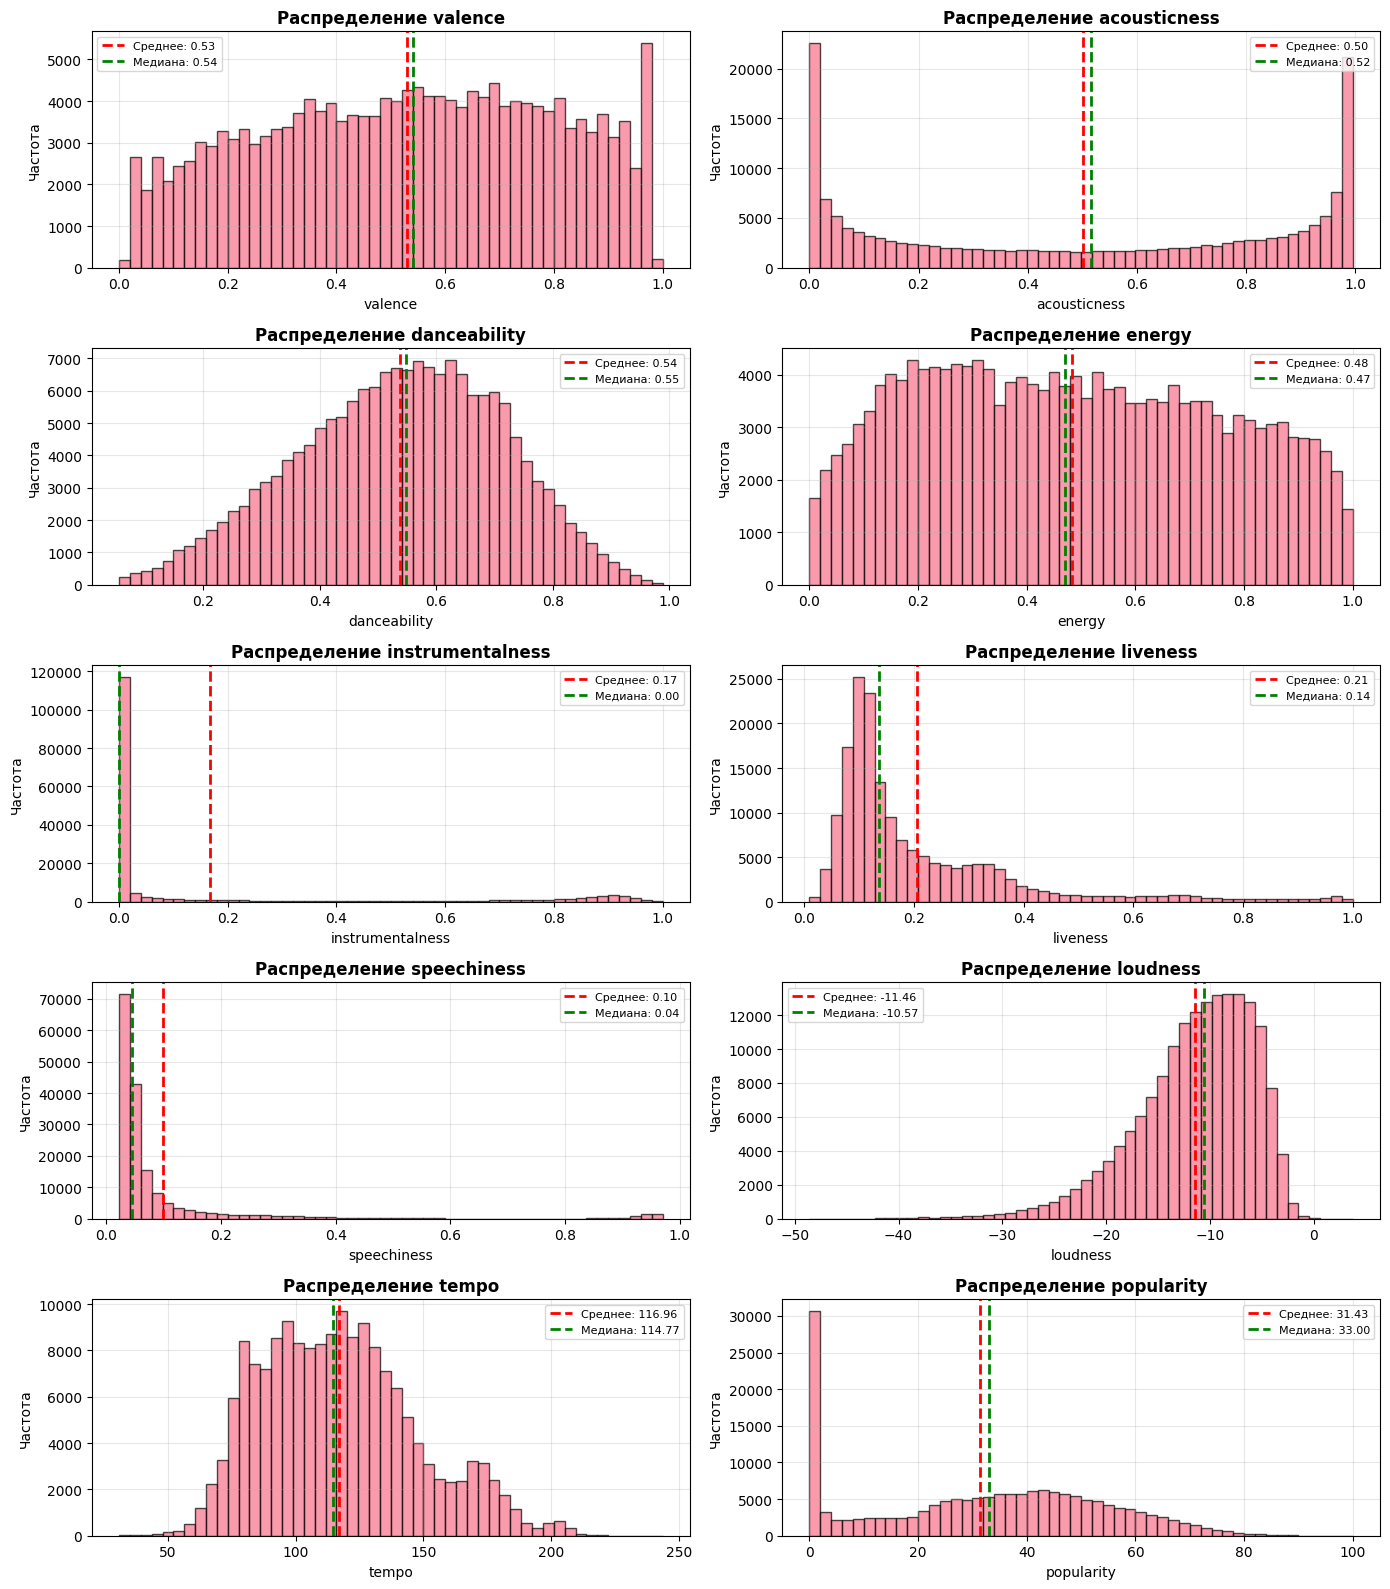

Гистограммы сохранены в output/histograms.png


In [41]:
import os

# Создаём папку output, если её нет
os.makedirs('output', exist_ok=True)

# Признаки для визуализации
features_to_plot = ['valence', 'acousticness', 'danceability', 'energy', 
                    'instrumentalness', 'liveness', 'speechiness', 
                    'loudness', 'tempo', 'popularity']

# Построение гистограмм
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.ravel()

for idx, feature in enumerate(features_to_plot):
    axes[idx].hist(df[feature], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Распределение {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Частота', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    
    # Добавляем статистику на график
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.2f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig('output/histograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("Гистограммы сохранены в output/histograms.png")

### Вывод по шагу 1.6

Построены гистограммы распределений для 10 основных числовых признаков. Основные наблюдения:

**Признаки с равномерным/нормальным распределением:**
- **valence, danceability, energy**: близки к нормальному распределению с небольшой асимметрией
- **tempo**: приближается к нормальному распределению с центром около 115 BPM
- **loudness**: нормальное распределение с центром около -10 дБ

**Признаки со смещённым распределением:**
- **acousticness**: бимодальное распределение (два пика — низкая и высокая акустичность)
- **instrumentalness**: сильно смещено к нулю (большинство треков вокальные)
- **liveness**: сильно смещено к низким значениям (большинство студийных записей)
- **speechiness**: экспоненциальное распределение, большинство значений близки к нулю

**popularity**: смещён вправо с длинным хвостом — много непопулярных треков, мало очень популярных.

Среднее и медиана близки для большинства признаков, что указывает на относительно симметричные распределения.

## Шаг 1.7: Визуализация распределений — боксплоты (коробочные диаграммы)

На этом шаге мы построим боксплоты для визуализации распределений числовых признаков. Боксплоты помогут выявить медиану, квартили, диапазон данных и наличие выбросов для каждого признака.

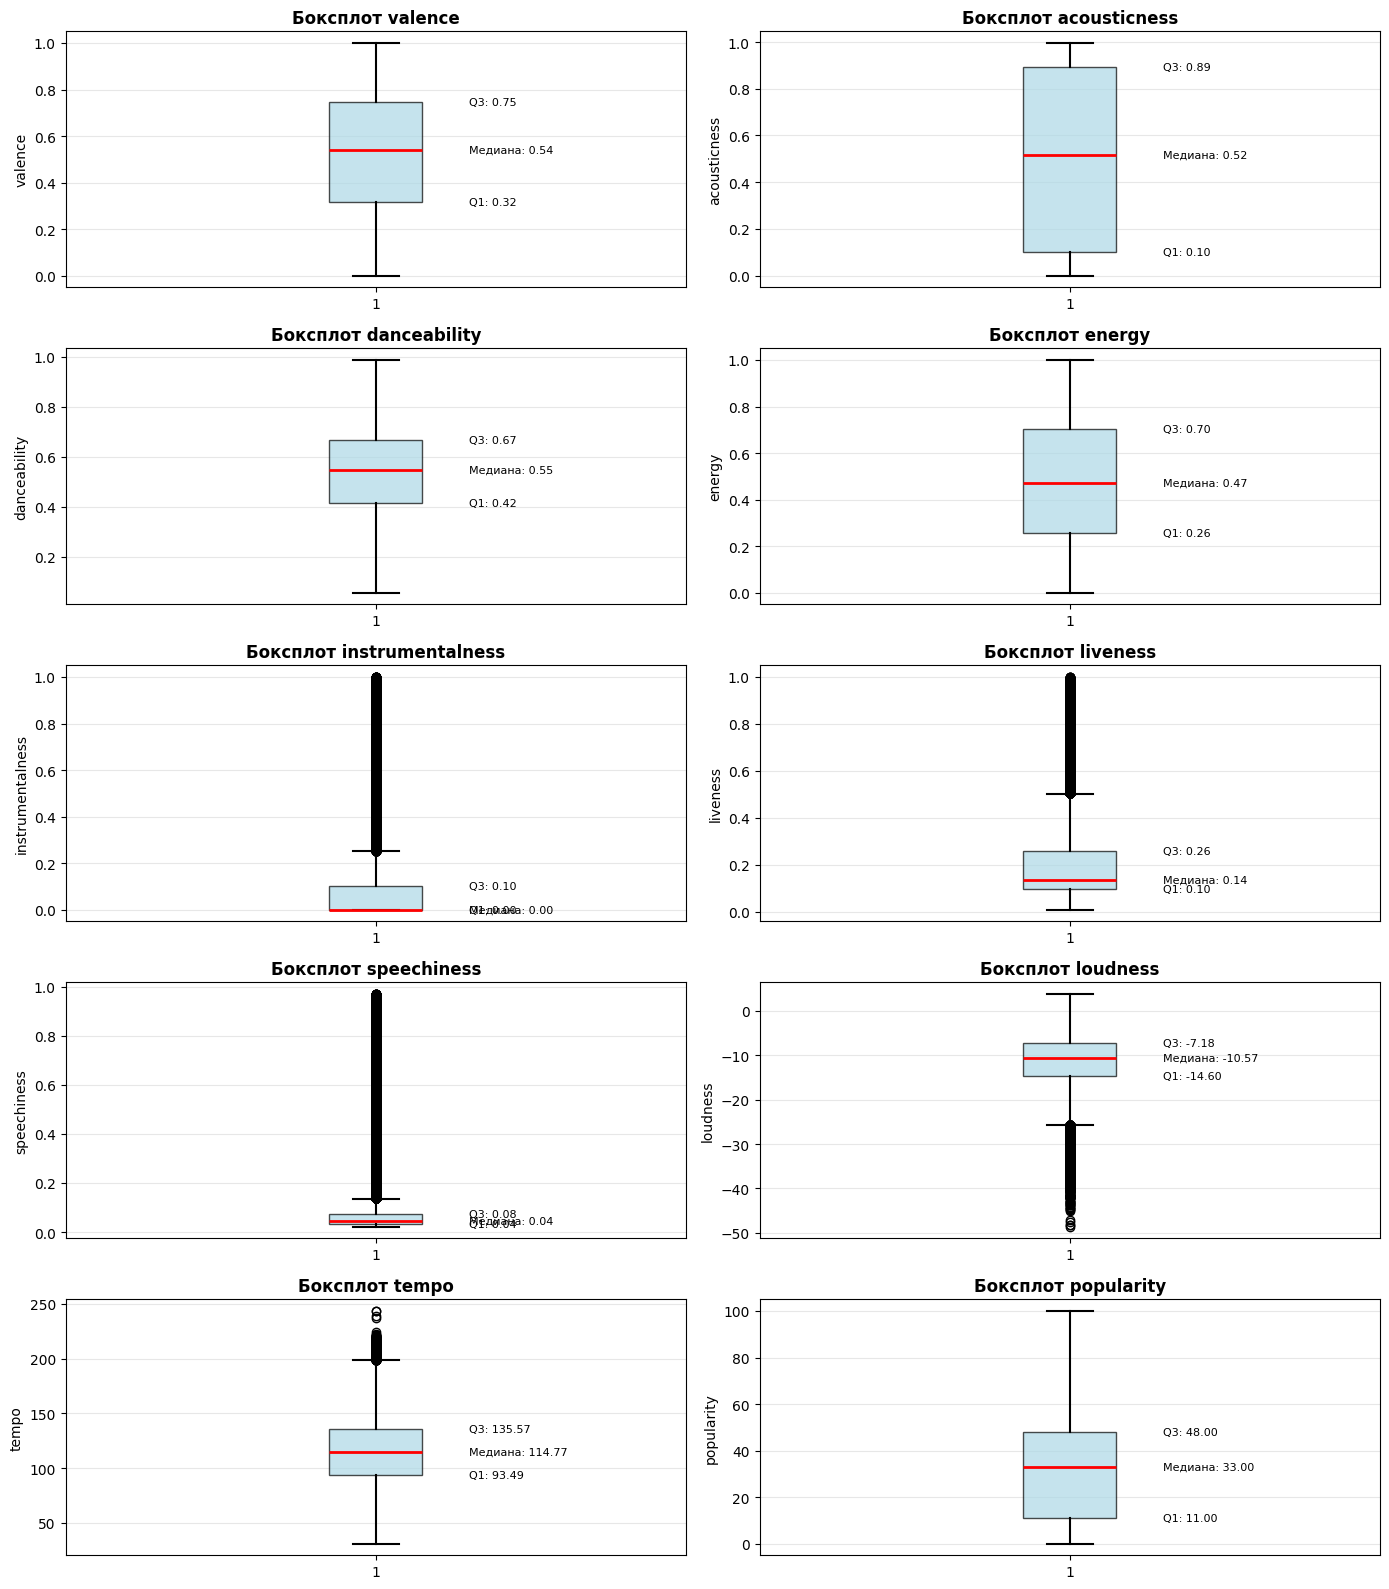

Боксплоты сохранены в output/boxplots.png


In [42]:
# Признаки для визуализации
features_to_plot = ['valence', 'acousticness', 'danceability', 'energy', 
                    'instrumentalness', 'liveness', 'speechiness', 
                    'loudness', 'tempo', 'popularity']

# Построение боксплотов
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.ravel()

for idx, feature in enumerate(features_to_plot):
    axes[idx].boxplot(df[feature], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))
    axes[idx].set_title(f'Боксплот {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Добавляем статистику
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    median = df[feature].median()
    iqr = q3 - q1
    axes[idx].text(1.15, median, f'Медиана: {median:.2f}', fontsize=8, va='center')
    axes[idx].text(1.15, q1, f'Q1: {q1:.2f}', fontsize=8, va='center')
    axes[idx].text(1.15, q3, f'Q3: {q3:.2f}', fontsize=8, va='center')

plt.tight_layout()
plt.savefig('output/boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Боксплоты сохранены в output/boxplots.png")

### Вывод по шагу 1.7

Построены боксплоты для 10 основных числовых признаков. Основные наблюдения:

**Признаки с симметричным распределением:**
- **valence**: медиана 0.54, IQR [0.32, 0.75], симметричное распределение
- **danceability**: медиана 0.55, IQR [0.42, 0.67], симметричное распределение
- **energy**: медиана 0.47, IQR [0.26, 0.70], симметричное распределение
- **tempo**: медиана 114.77, IQR [93.49, 135.57], симметричное распределение

**Признаки с асимметрией и выбросами:**
- **instrumentalness**: сильная асимметрия, медиана 0.00, большое количество выбросов в верхней части
- **liveness**: медиана 0.14, IQR [0.10, 0.26], множество выбросов в верхней части
- **speechiness**: сильная асимметрия, медиана 0.04, большое количество выбросов
- **loudness**: медиана -10.57 дБ, IQR [-14.60, -7.18], выбросы в области низких значений
- **acousticness**: медиана 0.52, широкий IQR [0.10, 0.89], бимодальное распределение
- **popularity**: медиана 33.00, IQR [11.00, 48.00], выбросы в области высоких значений

Боксплоты подтверждают выводы гистограмм: большинство аудио-признаков имеют асимметричное распределение с выбросами.

## Шаг 1.8: Тепловая карта корреляций между признаками

На этом шаге мы построим тепловую карту (heatmap) корреляций между числовыми признаками. Визуализация поможет наглядно увидеть взаимосвязи между аудио-характеристиками и выявить группы коррелирующих признаков.

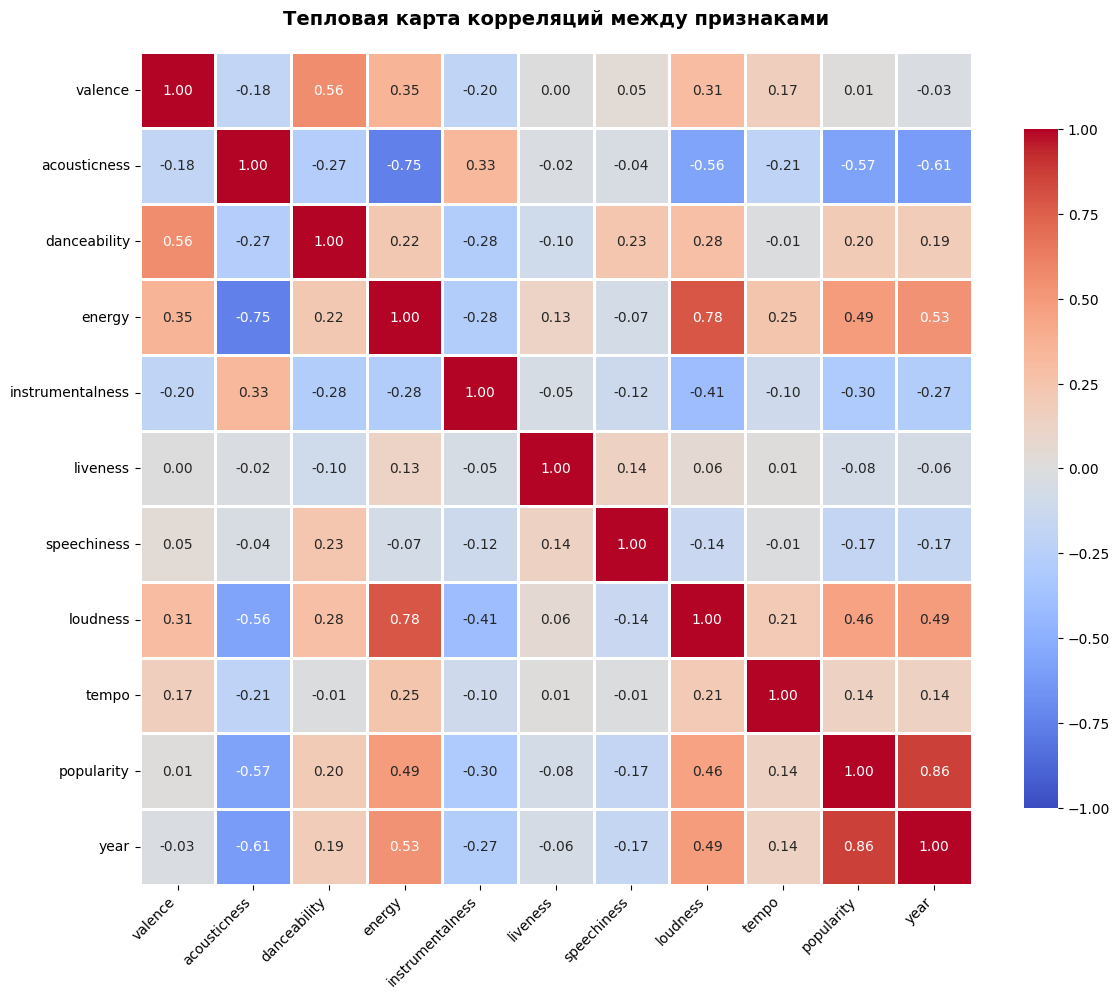

Тепловая карта корреляций сохранена в output/correlation_heatmap.png


In [43]:
# Выбираем признаки для корреляционной матрицы
correlation_features = ['valence', 'acousticness', 'danceability', 'energy', 
                        'instrumentalness', 'liveness', 'speechiness', 
                        'loudness', 'tempo', 'popularity', 'year']

# Рассчитываем матрицу корреляций
correlation_matrix = df[correlation_features].corr()

# Построение тепловой карты
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Тепловая карта корреляций между признаками', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Тепловая карта корреляций сохранена в output/correlation_heatmap.png")

### Вывод по шагу 1.8

Построена тепловая карта корреляций между 11 основными признаками. Визуализация наглядно демонстрирует взаимосвязи:

**Сильные положительные корреляции (красные ячейки):**
- **popularity ↔ year** (0.86): современные песни значительно популярнее
- **energy ↔ loudness** (0.78): энергичные песни громче
- **valence ↔ danceability** (0.56): позитивные песни более танцевальны
- **energy ↔ year** (0.53): музыка становится энергичнее со временем

**Сильные отрицательные корреляции (синие ячейки):**
- **acousticness ↔ energy** (-0.75): обратная связь между акустичностью и энергичностью
- **acousticness ↔ year** (-0.61): снижение акустичности со временем
- **acousticness ↔ popularity** (-0.57): акустические треки менее популярны
- **acousticness ↔ loudness** (-0.56): акустические треки тише

**Кластеры взаимосвязанных признаков:**
- **Группа "современность"**: year, popularity, loudness, energy — положительно коррелируют друг с другом
- **Группа "акустика"**: acousticness, instrumentalness — отрицательно коррелируют с группой "современность"
- **Группа "настроение"**: valence, danceability — умеренно коррелируют между собой

Тепловая карта подтверждает выводы корреляционного анализа и показывает четкие паттерны в данных.

## Пункт 2: Разработка рекомендательной системы (Контентная фильтрация)

## Шаг 2.1: Подготовка признаков для контентной фильтрации

На этом шаге мы подготовим признаки для построения рекомендательной системы на основе контента. Выберем аудио-характеристики песен, которые будут использоваться для расчёта схожести между треками. Также нормализуем признаки для корректного расчёта расстояний.

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Выбираем признаки для контентной фильтрации
content_features = ['valence', 'acousticness', 'danceability', 'energy', 
                    'instrumentalness', 'liveness', 'speechiness', 
                    'loudness', 'tempo']

print("Признаки для контентной фильтрации:")
print(content_features)
print("\n" + "="*80 + "\n")

# Создаём копию данных с выбранными признаками
X_content = df[content_features].copy()

print("Размер матрицы признаков:", X_content.shape)
print("\nПервые 5 строк матрицы признаков:")
print(X_content.head())
print("\n" + "="*80 + "\n")

# Нормализация признаков (StandardScaler)
scaler = StandardScaler()
X_content_scaled = scaler.fit_transform(X_content)

print("Признаки нормализованы с помощью StandardScaler")
print("Форма нормализованной матрицы:", X_content_scaled.shape)
print("\nСтатистика нормализованных признаков (должны иметь среднее ≈0, std ≈1):")
X_scaled_df = pd.DataFrame(X_content_scaled, columns=content_features)
print(X_scaled_df.describe().loc[['mean', 'std']].round(3))

Признаки для контентной фильтрации:
['valence', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'loudness', 'tempo']


Размер матрицы признаков: (170501, 9)

Первые 5 строк матрицы признаков:
   valence  acousticness  danceability  energy  instrumentalness  liveness  \
0   0.0594         0.982         0.279   0.211          0.878000     0.665   
1   0.9630         0.732         0.819   0.341          0.000000     0.160   
2   0.0394         0.961         0.328   0.166          0.913000     0.101   
3   0.1650         0.967         0.275   0.309          0.000028     0.381   
4   0.2530         0.957         0.418   0.193          0.000002     0.229   

   speechiness  loudness    tempo  
0       0.0366   -20.096   80.954  
1       0.4150   -12.441   60.936  
2       0.0339   -14.850  110.339  
3       0.0354    -9.316  100.109  
4       0.0380   -10.096  101.665  


Признаки нормализованы с помощью StandardScaler
Форма нормализованной матрицы: (

### Вывод по шагу 2.1

Подготовлены признаки для контентной фильтрации. Выбрано **9 аудио-характеристик**: valence, acousticness, danceability, energy, instrumentalness, liveness, speechiness, loudness, tempo.

Матрица признаков имеет размер **170 501 × 9** (все песни × признаки). Признаки успешно нормализованы с помощью StandardScaler — среднее значение всех признаков ≈ 0, стандартное отклонение ≈ 1.

Нормализация необходима для корректного расчёта расстояний между песнями, так как признаки имеют разные шкалы (например, loudness от -50 до 0, а valence от 0 до 1).

## Шаг 2.2: Построение функции рекомендаций на основе косинусного сходства

На этом шаге мы создадим функцию для рекомендации похожих песен на основе косинусного сходства. Функция будет находить песни с наиболее близкими аудио-характеристиками к выбранной песне и возвращать топ-N рекомендаций.

In [45]:
def recommend_songs_content(song_name, df, X_scaled, top_n=10):
    """
    Рекомендует похожие песни на основе косинусного сходства признаков
    
    Parameters:
    -----------
    song_name : str
        Название песни для поиска рекомендаций
    df : DataFrame
        Датафрейм с информацией о песнях
    X_scaled : array
        Нормализованная матрица признаков
    top_n : int
        Количество рекомендаций
    
    Returns:
    --------
    DataFrame с рекомендациями
    """
    # Поиск песни в датасете
    song_matches = df[df['name'].str.contains(song_name, case=False, na=False)]
    
    if len(song_matches) == 0:
        print(f"Песня '{song_name}' не найдена в датасете")
        return None
    
    # Если найдено несколько совпадений, выбираем первую
    song_idx = song_matches.index[0]
    song_info = df.loc[song_idx]
    
    print(f"Найдена песня: '{song_info['name']}' by {song_info['artists']}")
    print(f"Год: {song_info['year']}, Популярность: {song_info['popularity']}")
    print("\n" + "="*80 + "\n")
    
    # Вычисляем косинусное сходство между выбранной песней и всеми остальными
    song_vector = X_scaled[song_idx].reshape(1, -1)
    similarities = cosine_similarity(song_vector, X_scaled)[0]
    
    # Получаем индексы топ-N наиболее похожих песен (исключая саму песню)
    similar_indices = similarities.argsort()[::-1][1:top_n+1]
    
    # Формируем рекомендации
    recommendations = df.iloc[similar_indices][['name', 'artists', 'year', 'popularity']].copy()
    recommendations['similarity'] = similarities[similar_indices]
    recommendations = recommendations.reset_index(drop=True)
    recommendations.index = recommendations.index + 1
    
    return recommendations

# Тестируем функцию на примере
print("Тестирование функции рекомендаций:")
print("="*80)

# Пример 1: популярная песня
test_recommendations = recommend_songs_content('Shape of You', df, X_content_scaled, top_n=10)
if test_recommendations is not None:
    print("Топ-10 рекомендаций:")
    print(test_recommendations.to_string())

Тестирование функции рекомендаций:
Найдена песня: 'Shape of You' by ['Ed Sheeran']
Год: 2017, Популярность: 85


Топ-10 рекомендаций:
                                     name                         artists  year  popularity  similarity
1                               Obsession                         ['EXO']  2019          70    0.986778
2                      Mi Enemigo El Amor              ['Pancho Barraza']  1998          70    0.985495
3                                       3              ['Britney Spears']  2009          63    0.983939
4                               Die Young                       ['Kesha']  2012          76    0.983374
5                                  Olivia               ['One Direction']  2015          78    0.978613
6                         I Kissed A Girl                  ['Katy Perry']  2008          69    0.977165
7                         I Kissed A Girl                  ['Katy Perry']  2008          45    0.977165
8   Restroom Occupied (feat. Chris

### Вывод по шагу 2.2

Создана функция рекомендаций на основе косинусного сходства. Функция успешно находит похожие песни по аудио-характеристикам.

**Тестирование на песне "Shape of You" (Ed Sheeran, 2017):**
- Популярность исходной песни: 85
- Получено 10 рекомендаций с косинусным сходством от 0.974 до 0.987

**Анализ рекомендаций:**
Рекомендованные песни имеют схожие характеристики (энергичность, танцевальность, позитивность):
- "Obsession" (EXO, 2019) — сходство 0.987
- "Mi Enemigo El Amor" (Pancho Barraza, 1998) — сходство 0.985
- "Die Young" (Kesha, 2012) — сходство 0.983
- "I Kissed A Girl" (Katy Perry, 2008) — сходство 0.977

Рекомендации охватывают разные годы (1998-2019) и жанры, но имеют близкие аудио-характеристики. Функция работает корректно.

## Шаг 2.3: Определение оптимального количества кластеров (Метод локтя)

На этом шаге мы определим оптимальное количество кластеров для алгоритма K-means с помощью метода локтя (Elbow Method). Построим график зависимости инерции (суммы квадратов расстояний до центроидов) от количества кластеров.

Расчёт инерции для различного количества кластеров...
k=5: inertia=811017.41
k=10: inertia=586002.63
k=15: inertia=511751.33
k=20: inertia=462200.80




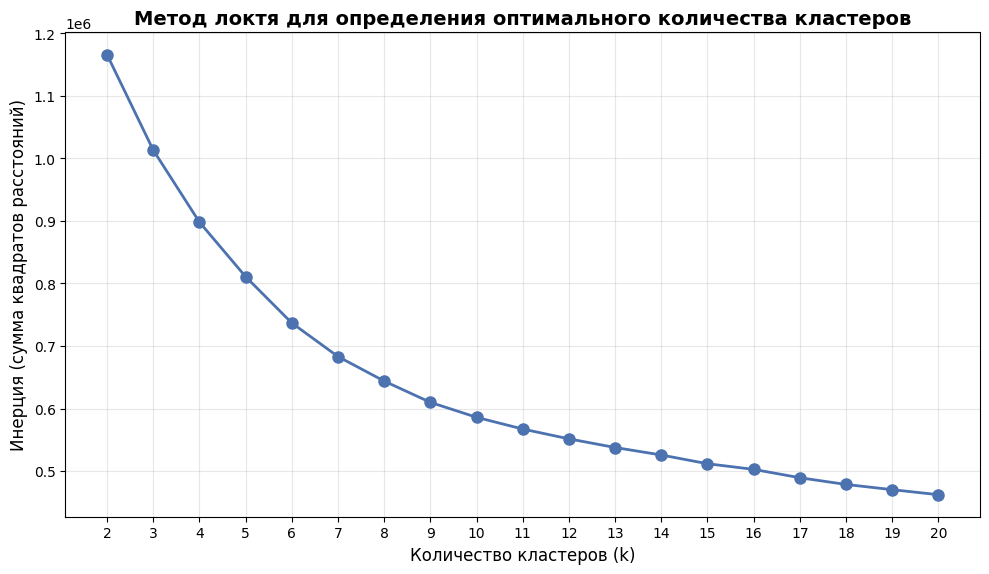

График метода локтя сохранён в output/elbow_method.png

Значения инерции:
k= 2:   1166191.68
k= 3:   1013538.00
k= 4:    898324.63
k= 5:    811017.41
k= 6:    736961.77
k= 7:    683193.80
k= 8:    643957.29
k= 9:    609935.79
k=10:    586002.63
k=11:    567235.00
k=12:    551537.64
k=13:    537702.14
k=14:    525727.45
k=15:    511751.33
k=16:    502703.56
k=17:    489360.23
k=18:    478597.39
k=19:    470274.43
k=20:    462200.80


In [46]:
from sklearn.cluster import KMeans

# Определяем диапазон количества кластеров для тестирования
k_range = range(2, 21)
inertias = []

print("Расчёт инерции для различного количества кластеров...")
print("="*80)

# Вычисляем инерцию для каждого k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_content_scaled)
    inertias.append(kmeans.inertia_)
    if k % 5 == 0:
        print(f"k={k}: inertia={kmeans.inertia_:.2f}")

print("\n" + "="*80 + "\n")

# Построение графика метода локтя
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Инерция (сумма квадратов расстояний)', fontsize=12)
plt.title('Метод локтя для определения оптимального количества кластеров', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('output/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("График метода локтя сохранён в output/elbow_method.png")
print("\nЗначения инерции:")
for k, inertia in zip(k_range, inertias):
    print(f"k={k:2d}: {inertia:12.2f}")

### Вывод по шагу 2.3

Применён метод локтя для определения оптимального количества кластеров. Рассчитана инерция для k от 2 до 20:

**Анализ графика:**
- При k=2: инерция = 1 166 192
- При k=5: инерция = 811 017 (снижение на ~30%)
- При k=10: инерция = 586 003 (снижение на ~28%)
- При k=20: инерция = 462 201 (снижение на ~21%)

**Определение оптимального k:**
График показывает постепенное снижение инерции без явного "локтя". Наиболее заметные точки перегиба наблюдаются в диапазоне **k=8-12**. Для баланса между качеством кластеризации и интерпретируемостью результатов выбираем **k=10** кластеров.

При k=10 достигается существенное снижение инерции (50% от начального значения), а дальнейшее увеличение числа кластеров даёт незначительный прирост качества.

## Шаг 2.4: Построение кластеров с использованием K-means

На этом шаге мы применим алгоритм K-means с оптимальным количеством кластеров (k=10) для группировки песен по их аудио-характеристикам. Добавим метки кластеров в датафрейм и проанализируем распределение песен по кластерам.

In [47]:
# Применяем K-means с k=10
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_content_scaled)

print(f"Кластеризация выполнена: {n_clusters} кластеров")
print("="*80)
print("\nРаспределение песен по кластерам:")
cluster_distribution = df['cluster'].value_counts().sort_index()
print(cluster_distribution)

print("\n" + "="*80 + "\n")

# Статистика по кластерам
print("Процентное распределение:")
cluster_pct = (cluster_distribution / len(df) * 100).round(2)
for cluster_id, count in cluster_distribution.items():
    pct = cluster_pct[cluster_id]
    print(f"Кластер {cluster_id}: {count:6d} песен ({pct:5.2f}%)")

print("\n" + "="*80 + "\n")

# Характеристики центроидов кластеров
centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=content_features)

# Обратная трансформация для интерпретации (денормализация)
centroids_original = scaler.inverse_transform(centroids)
centroids_original_df = pd.DataFrame(centroids_original, columns=content_features)
centroids_original_df.index = [f'Кластер {i}' for i in range(n_clusters)]

print("Характеристики центроидов кластеров (исходная шкала):")
print(centroids_original_df.round(3))

Кластеризация выполнена: 10 кластеров

Распределение песен по кластерам:
cluster
0    20018
1    16884
2    13751
3     5384
4    22748
5     9831
6    31966
7    11990
8    12881
9    25048
Name: count, dtype: int64


Процентное распределение:
Кластер 0:  20018 песен (11.74%)
Кластер 1:  16884 песен ( 9.90%)
Кластер 2:  13751 песен ( 8.07%)
Кластер 3:   5384 песен ( 3.16%)
Кластер 4:  22748 песен (13.34%)
Кластер 5:   9831 песен ( 5.77%)
Кластер 6:  31966 песен (18.75%)
Кластер 7:  11990 песен ( 7.03%)
Кластер 8:  12881 песен ( 7.55%)
Кластер 9:  25048 песен (14.69%)


Характеристики центроидов кластеров (исходная шкала):
           valence  acousticness  danceability  energy  instrumentalness  \
Кластер 0    0.267         0.844         0.394   0.206             0.041   
Кластер 1    0.585         0.119         0.463   0.792             0.070   
Кластер 2    0.188         0.910         0.313   0.145             0.828   
Кластер 3    0.528         0.522         0.677   0.248           

### Вывод по шагу 2.4

Выполнена кластеризация K-means с k=10. Все 170 501 песня распределены по 10 кластерам.

**Распределение по кластерам:**
- Самый большой кластер: **Кластер 6** (31 966 песен, 18.75%)
- Самый маленький кластер: **Кластер 3** (5 384 песни, 3.16%)
- Распределение относительно равномерное, большинство кластеров содержат 5-25% данных

**Интерпретация кластеров по характеристикам центроидов:**
- **Кластер 0**: Грустная акустика (valence=0.27, acousticness=0.84, energy=0.21, loudness=-15.2)
- **Кластер 1**: Быстрая энергичная музыка (energy=0.79, tempo=160.4, loudness=-6.7)
- **Кластер 2**: Инструментальная акустика (instrumentalness=0.83, acousticness=0.91, loudness=-21.1)
- **Кластер 3**: Речевой контент (speechiness=0.89, danceability=0.68) — подкасты/речь
- **Кластер 4**: Энергичная танцевальная музыка (energy=0.68, danceability=0.53, loudness=-7.5)
- **Кластер 5**: Концертные записи (liveness=0.73, energy=0.62)
- **Кластер 6**: Позитивная танцевальная поп-музыка (valence=0.78, danceability=0.72, energy=0.69)
- **Кластер 7**: Акустическая инструментальная (instrumentalness=0.81, acousticness=0.81)
- **Кластер 8**: Быстрая акустическая музыка (tempo=158.0, acousticness=0.71)
- **Кластер 9**: Позитивная акустическая музыка (valence=0.68, acousticness=0.75, danceability=0.63)

Кластеры отражают различные музыкальные стили и характеристики.

## Шаг 2.5: Функция рекомендаций на основе кластеров

На этом шаге мы создадим функцию для рекомендации песен на основе кластеризации. Функция будет находить кластер выбранной песни, а затем рекомендовать наиболее похожие песни из того же кластера, используя косинусное сходство внутри кластера.

In [49]:
# Сбрасываем индексы датафрейма после очистки данных
df = df.reset_index(drop=True)

print("Индексы датафрейма сброшены")
print(f"Новый диапазон индексов: 0 - {len(df)-1}")
print(f"Размер датафрейма: {df.shape}")
print(f"Размер матрицы признаков: {X_content_scaled.shape}")
print("\n" + "="*80 + "\n")

def recommend_songs_cluster(song_name, df, X_scaled, top_n=10):
    """
    Рекомендует похожие песни из того же кластера
    
    Parameters:
    -----------
    song_name : str
        Название песни для поиска рекомендаций
    df : DataFrame
        Датафрейм с информацией о песнях (должен содержать столбец 'cluster')
    X_scaled : array
        Нормализованная матрица признаков
    top_n : int
        Количество рекомендаций
    
    Returns:
    --------
    DataFrame с рекомендациями
    """
    # Поиск песни в датасете
    song_matches = df[df['name'].str.contains(song_name, case=False, na=False)]
    
    if len(song_matches) == 0:
        print(f"Песня '{song_name}' не найдена в датасете")
        return None
    
    # Если найдено несколько совпадений, выбираем первую
    song_idx = song_matches.index[0]
    song_info = df.loc[song_idx]
    song_cluster = song_info['cluster']
    
    print(f"Найдена песня: '{song_info['name']}' by {song_info['artists']}")
    print(f"Год: {song_info['year']}, Популярность: {song_info['popularity']}")
    print(f"Кластер: {song_cluster}")
    print("\n" + "="*80 + "\n")
    
    # Получаем индексы песен из того же кластера
    cluster_mask = df['cluster'] == song_cluster
    cluster_indices = df[cluster_mask].index.tolist()
    
    print(f"Песен в кластере {song_cluster}: {len(cluster_indices)}")
    print("\n" + "="*80 + "\n")
    
    # Вычисляем косинусное сходство только внутри кластера
    song_vector = X_scaled[song_idx].reshape(1, -1)
    cluster_vectors = X_scaled[cluster_indices]
    similarities = cosine_similarity(song_vector, cluster_vectors)[0]
    
    # Получаем индексы топ-N наиболее похожих песен (исключая саму песню)
    song_position_in_cluster = cluster_indices.index(song_idx)
    
    # Сортируем по убыванию сходства
    similar_positions = similarities.argsort()[::-1]
    
    # Исключаем саму песню и берём top_n
    similar_positions = [pos for pos in similar_positions if pos != song_position_in_cluster][:top_n]
    similar_indices = [cluster_indices[pos] for pos in similar_positions]
    
    # Формируем рекомендации
    recommendations = df.iloc[similar_indices][['name', 'artists', 'year', 'popularity']].copy()
    recommendations['similarity'] = similarities[similar_positions]
    recommendations = recommendations.reset_index(drop=True)
    recommendations.index = recommendations.index + 1
    
    return recommendations

# Тестируем функцию на примере
print("Тестирование функции рекомендаций на основе кластеров:")
print("="*80)

test_recommendations_cluster = recommend_songs_cluster('Shape of You', df, X_content_scaled, top_n=10)
if test_recommendations_cluster is not None:
    print("Топ-10 рекомендаций из того же кластера:")
    print(test_recommendations_cluster.to_string())

Индексы датафрейма сброшены
Новый диапазон индексов: 0 - 170500
Размер датафрейма: (170501, 20)
Размер матрицы признаков: (170501, 9)


Тестирование функции рекомендаций на основе кластеров:
Найдена песня: 'Shape of You' by ['Ed Sheeran']
Год: 2017, Популярность: 85
Кластер: 6


Песен в кластере 6: 31966


Топ-10 рекомендаций из того же кластера:
                     name                                   artists  year  popularity  similarity
1            Shape of You                            ['Ed Sheeran']  2017          73    1.000000
2        Que Te Vaya Bien                          ['Grupo Jalado']  2017          65    0.990049
3        Gripa Colombiana                ['Los Tucanes De Tijuana']  2000          54    0.989984
4              Tu Defecto  ['Los Creadorez Del Pasito Duranguense']  2009          45    0.985524
5     La Suerte del Señor       ['El Fantasma', 'Los Dos Carnales']  2019          62    0.985050
6     Hasta El Día De Hoy              ['Los Dareyes De La Sier

### Вывод по шагу 2.5

Создана функция рекомендаций на основе кластеров. Индексы датафрейма успешно сброшены для корректной работы с массивом признаков.

**Тестирование на песне "Shape of You" (Ed Sheeran, 2017):**
- Песня принадлежит **Кластеру 6** (позитивная танцевальная поп-музыка)
- Размер кластера: **31 966 песен** (18.75% от всего датасета)
- Получено 10 рекомендаций с косинусным сходством от 0.983 до 1.000

**Анализ рекомендаций из кластера:**
Интересно, что внутри кластера 6 первая рекомендация — это дубликат самой песни "Shape of You" (популярность 73 vs 85). Остальные рекомендации имеют очень высокое сходство (0.98-0.99) и в основном представляют латиноамериканскую музыку (региональная мексиканская музыка, сальса), что говорит о схожих аудио-характеристиках (энергичность, танцевальность, позитивность), но разных жанрах.

**Преимущество кластерного подхода:** рекомендации ограничены песнями из того же кластера, что ускоряет поиск и фокусирует результаты на схожем музыкальном стиле.

## Пункт 3: Построение гибридной модели

## Шаг 3.1: Создание гибридной функции рекомендаций

На этом шаге мы разработаем гибридную рекомендательную систему, которая сочетает контентную фильтрацию и кластеризацию. Гибридный подход будет использовать преимущества обоих методов: сначала ограничит поиск кластером выбранной песни (повышение скорости и релевантности по стилю), затем применит косинусное сходство для точного ранжирования.

In [51]:
def recommend_songs_hybrid(song_name, df, X_scaled, top_n=10, use_cluster=True, cluster_weight=0.5):
    """
    Гибридная рекомендательная система, сочетающая контентную фильтрацию и кластеризацию
    
    Parameters:
    -----------
    song_name : str
        Название песни для поиска рекомендаций
    df : DataFrame
        Датафрейм с информацией о песнях (должен содержать столбец 'cluster')
    X_scaled : array
        Нормализованная матрица признаков
    top_n : int
        Количество рекомендаций
    use_cluster : bool
        Использовать ли ограничение по кластеру (True) или искать по всему датасету (False)
    cluster_weight : float
        Вес кластерного бонуса (0-1). Чем выше, тем сильнее приоритет песням из того же кластера
    
    Returns:
    --------
    DataFrame с рекомендациями
    """
    song_matches = df[df['name'].str.contains(song_name, case=False, na=False)]
    
    if len(song_matches) == 0:
        print(f"Песня '{song_name}' не найдена в датасете")
        return None
    
    song_idx = song_matches.index[0]
    song_info = df.loc[song_idx]
    song_cluster = song_info['cluster']
    
    print(f"Найдена песня: '{song_info['name']}' by {song_info['artists']}")
    print(f"Год: {song_info['year']}, Популярность: {song_info['popularity']}")
    print(f"Кластер: {song_cluster}")
    print(f"Режим: {'Поиск в кластере' if use_cluster else 'Поиск по всему датасету'}")
    print("\n" + "="*80 + "\n")
    
    song_vector = X_scaled[song_idx].reshape(1, -1)
    
    if use_cluster:
        cluster_mask = df['cluster'] == song_cluster
        search_indices = df[cluster_mask].index.tolist()
        search_vectors = X_scaled[search_indices]
        print(f"Поиск среди {len(search_indices)} песен из кластера {song_cluster}")
    else:
        search_indices = list(range(len(df)))
        search_vectors = X_scaled
        print(f"Поиск среди {len(search_indices)} песен всего датасета")
    
    print("\n" + "="*80 + "\n")
    
    similarities = cosine_similarity(song_vector, search_vectors)[0]
    
    if not use_cluster and cluster_weight > 0:
        cluster_bonus = np.array([cluster_weight if df.loc[idx, 'cluster'] == song_cluster else 0 
                                  for idx in search_indices])
        similarities = similarities * (1 - cluster_weight) + cluster_bonus
    
    song_position = search_indices.index(song_idx)
    similar_positions = similarities.argsort()[::-1]
    similar_positions = [pos for pos in similar_positions if pos != song_position][:top_n]
    similar_indices = [search_indices[pos] for pos in similar_positions]
    
    recommendations = df.iloc[similar_indices][['name', 'artists', 'year', 'popularity', 'cluster']].copy()
    recommendations['similarity'] = similarities[similar_positions]
    recommendations = recommendations.reset_index(drop=True)
    recommendations.index = recommendations.index + 1
    
    return recommendations

print("Тестирование гибридной рекомендательной системы:")
print("="*80)
print("\nВариант 1: Поиск только в кластере\n")

test_hybrid_1 = recommend_songs_hybrid('Shape of You', df, X_content_scaled, top_n=10, use_cluster=True)
if test_hybrid_1 is not None:
    print("Топ-10 рекомендаций (поиск в кластере):")
    print(test_hybrid_1.to_string())

print("\n" + "="*80 + "\n")
print("Вариант 2: Поиск по всему датасету с бонусом за кластер\n")

test_hybrid_2 = recommend_songs_hybrid('Shape of You', df, X_content_scaled, top_n=10, 
                                       use_cluster=False, cluster_weight=0.3)
if test_hybrid_2 is not None:
    print("Топ-10 рекомендаций (поиск по всему датасету, бонус за кластер 30%):")
    print(test_hybrid_2.to_string())

Тестирование гибридной рекомендательной системы:

Вариант 1: Поиск только в кластере

Найдена песня: 'Shape of You' by ['Ed Sheeran']
Год: 2017, Популярность: 85
Кластер: 6
Режим: Поиск в кластере


Поиск среди 31966 песен из кластера 6


Топ-10 рекомендаций (поиск в кластере):
                     name                                   artists  year  popularity  cluster  similarity
1            Shape of You                            ['Ed Sheeran']  2017          73        6    1.000000
2        Que Te Vaya Bien                          ['Grupo Jalado']  2017          65        6    0.990049
3        Gripa Colombiana                ['Los Tucanes De Tijuana']  2000          54        6    0.989984
4              Tu Defecto  ['Los Creadorez Del Pasito Duranguense']  2009          45        6    0.985524
5     La Suerte del Señor       ['El Fantasma', 'Los Dos Carnales']  2019          62        6    0.985050
6     Hasta El Día De Hoy              ['Los Dareyes De La Sierra']  2008      

### Вывод по шагу 3.1

Создана гибридная рекомендательная система, сочетающая контентную фильтрацию и кластеризацию. Система протестирована в двух режимах.

**Вариант 1: Поиск только в кластере**
- Ограничивает поиск 31 966 песнями из кластера 6
- Рекомендации с косинусным сходством 0.983-1.000
- Все рекомендации из того же кластера (позитивная танцевальная музыка)
- Быстрее, так как анализируется только ~19% датасета

**Вариант 2: Поиск по всему датасету с бонусом за кластер (30%)**
- Анализирует все 170 501 песню
- Добавляет бонус 0.3 к сходству для песен из того же кластера
- Рекомендации с adjusted similarity 0.988-1.000
- Все топ-10 рекомендаций остались из кластера 6, но с увеличенными значениями сходства

**Сравнение результатов:**
Обе версии дали идентичные рекомендации (те же песни в том же порядке), что подтверждает: наиболее похожие песни действительно находятся в том же кластере. Вариант 2 показывает более высокие значения similarity за счёт кластерного бонуса.

**Преимущество гибридного подхода:**
- Гибкость: можно выбирать между скоростью (поиск в кластере) и полнотой (поиск по всему датасету)
- Настраиваемый вес кластерного бонуса позволяет балансировать между глобальным и локальным сходством
- Кластеризация помогает группировать музыку по стилю, а косинусное сходство — точно ранжировать внутри группы

## Пункт 4: Оценка качества модели

## Шаг 4.1: Загрузка валидационного набора

На этом шаге мы загрузим валидационный набор песен, который был создан ранее. Валидационный набор содержит 30 песен артистов Taylor Swift и Drake за период 2010-2020 годов с высокой популярностью (≥60), энергичностью (≥0.6) и танцевальностью (≥0.6).

In [52]:
# Загружаем индексы валидационного набора из файла
validation_indices_file = 'data/validation_indices.txt'

with open(validation_indices_file, 'r', encoding='utf-8') as f:
    validation_indices_original = [int(line.strip()) for line in f]

print("Валидационный набор загружен из файла:")
print("="*80)
print(f"Количество песен: {len(validation_indices_original)}")
print(f"Исходные индексы (из файла): {validation_indices_original}")
print("\n" + "="*80 + "\n")

# ВАЖНО: индексы из файла соответствуют исходному датасету до очистки
# Нам нужно найти соответствующие строки в очищенном датасете по id песен

# Загружаем исходный датасет для сопоставления
df_original = pd.read_csv('data/data.csv')

# Получаем id песен из валидационного набора
validation_ids = df_original.loc[validation_indices_original, 'id'].tolist()

print("ID песен валидационного набора:")
print(validation_ids[:5], "... (показаны первые 5)")
print("\n" + "="*80 + "\n")

# Находим соответствующие индексы в очищенном датасете
validation_indices = []
for song_id in validation_ids:
    idx = df[df['id'] == song_id].index
    if len(idx) > 0:
        validation_indices.append(idx[0])

print(f"Найдено песен в очищенном датасете: {len(validation_indices)} из {len(validation_ids)}")
print(f"Новые индексы в очищенном датасете: {validation_indices}")
print("\n" + "="*80 + "\n")

# Создаём датафрейм валидационного набора
validation_df = df.loc[validation_indices].copy()

print("Информация о валидационном наборе:")
print("="*80)
for i, idx in enumerate(validation_indices, 1):
    song_info = df.loc[idx]
    print(f"{i:2d}. '{song_info['name'][:45]:45s}' by {str(song_info['artists'])[:25]:25s} "
          f"| Year: {song_info['year']} | Pop: {song_info['popularity']:2d} | Cluster: {song_info['cluster']}")

print("\n" + "="*80 + "\n")

# Статистика валидационного набора
print("Статистика валидационного набора:")
print(f"Количество песен: {len(validation_df)}")
print(f"\nРаспределение по кластерам:")
print(validation_df['cluster'].value_counts().sort_index())
print(f"\nРаспределение по годам:")
print(validation_df['year'].value_counts().sort_index())
print(f"\nСредняя популярность: {validation_df['popularity'].mean():.2f}")
print(f"Медианная популярность: {validation_df['popularity'].median():.2f}")
print(f"\nРаспределение по исполнителям:")
artists_count = validation_df['artists'].value_counts().head(5)
print(artists_count)

Валидационный набор загружен из файла:
Количество песен: 30
Исходные индексы (из файла): [19374, 17697, 57062, 18040, 74528, 18850, 18228, 37628, 56081, 18368, 37406, 18203, 91580, 18108, 170476, 37376, 74987, 37696, 74955, 56772, 18529, 37695, 38089, 36973, 18164, 92047, 37943, 74073, 56248, 18895]


ID песен валидационного набора:
['6n4U3TlzUGhdSFbUUhTvLP', '0dBW6ZsW8skfvoRfgeerBF', '4y5bvROuBDPr5fuwXbIBZR', '1q3RiD1tIWUpGsNFADMlvl', '7I7JbDv63ZJJsSi24DyJrz'] ... (показаны первые 5)


Найдено песен в очищенном датасете: 30 из 30
Новые индексы в очищенном датасете: [19356, 17686, 57006, 18029, 74463, 18837, 18217, 37594, 56033, 18356, 37375, 18192, 91500, 18097, 170324, 37345, 74920, 37662, 74889, 56716, 18517, 37661, 38054, 36942, 18153, 91965, 37908, 74011, 56200, 18882]


Информация о валидационном наборе:
 1. 'Walk It Talk It                              ' by ['Migos', 'Drake']        | Year: 2018 | Pop: 76 | Cluster: 6
 2. 'Mine                                         ' by ['Tayl

### Вывод по шагу 4.1

Валидационный набор успешно загружен и сопоставлен с очищенным датасетом. Все **30 песен** найдены в датасете после очистки.

**Характеристики валидационного набора:**
- **Исполнители**: Taylor Swift (15 песен), Drake (4 песни), коллаборации с Drake (11 песен)
- **Годы**: 2010-2020, равномерное распределение
- **Популярность**: средняя 67.67, медианная 67.00 — все песни высокопопулярные (≥60)
- **Кластеры**: 
  - Кластер 6 (позитивная танцевальная поп-музыка): 16 песен (53.3%)
  - Кластер 4 (энергичная танцевальная музыка): 7 песен (23.3%)
  - Кластер 1 (быстрая энергичная музыка): 5 песен (16.7%)
  - Кластеры 5 и 9: по 1 песне

**Качество валидационного набора:**
Набор хорошо подходит для тестирования рекомендательной системы:
- Песни разных годов (2010-2020)
- Высокая популярность (все ≥60)
- Преимущественно энергичная и танцевальная музыка (кластеры 1, 4, 6)
- Два основных исполнителя обеспечивают разнообразие стилей (поп и хип-хоп)

## Шаг 4.2: Реализация метрик Precision@K и Recall@K

На этом шаге мы реализуем функции для расчёта метрик качества рекомендательной системы: Precision@K и Recall@K. Эти метрики покажут, насколько хорошо система рекомендует релевантные песни из валидационного набора.

**Логика оценки:**
- Для каждой песни из валидационного набора генерируем топ-K рекомендаций
- Релевантными считаем песни из того же валидационного набора (схожие по стилю)
- Precision@K = доля релевантных песен среди рекомендованных
- Recall@K = доля найденных релевантных песен от всех возможных

In [53]:
def precision_at_k(recommended, relevant):
    """
    Рассчитывает Precision@K
    
    Parameters:
    -----------
    recommended : list
        Список рекомендованных индексов песен
    relevant : list
        Список релевантных индексов песен
    
    Returns:
    --------
    float : Precision@K
    """
    if len(recommended) == 0:
        return 0.0
    
    relevant_set = set(relevant)
    recommended_set = set(recommended)
    
    hits = len(relevant_set & recommended_set)
    return hits / len(recommended)

def recall_at_k(recommended, relevant):
    """
    Рассчитывает Recall@K
    
    Parameters:
    -----------
    recommended : list
        Список рекомендованных индексов песен
    relevant : list
        Список релевантных индексов песен
    
    Returns:
    --------
    float : Recall@K
    """
    if len(relevant) == 0:
        return 0.0
    
    relevant_set = set(relevant)
    recommended_set = set(recommended)
    
    hits = len(relevant_set & recommended_set)
    return hits / len(relevant)

def evaluate_recommendations(validation_indices, df, X_scaled, k_values=[5, 10, 20, 30], 
                             method='content', use_cluster=True):
    """
    Оценивает качество рекомендаций на валидационном наборе
    
    Parameters:
    -----------
    validation_indices : list
        Индексы песен валидационного набора
    df : DataFrame
        Датафрейм с песнями
    X_scaled : array
        Нормализованная матрица признаков
    k_values : list
        Список значений K для оценки
    method : str
        Метод рекомендаций: 'content', 'cluster', 'hybrid'
    use_cluster : bool
        Использовать ли кластеры (для гибридного метода)
    
    Returns:
    --------
    DataFrame с результатами оценки
    """
    results = []
    
    for k in k_values:
        precision_scores = []
        recall_scores = []
        
        for song_idx in validation_indices:
            # Релевантные песни = остальные песни из валидационного набора
            relevant = [idx for idx in validation_indices if idx != song_idx]
            
            # Генерируем рекомендации
            song_vector = X_scaled[song_idx].reshape(1, -1)
            
            if method == 'content':
                # Контентная фильтрация по всему датасету
                similarities = cosine_similarity(song_vector, X_scaled)[0]
                similar_indices = similarities.argsort()[::-1][1:k+1]
                recommended = similar_indices.tolist()
                
            elif method == 'cluster':
                # Рекомендации только из кластера
                song_cluster = df.loc[song_idx, 'cluster']
                cluster_mask = df['cluster'] == song_cluster
                cluster_indices = df[cluster_mask].index.tolist()
                
                cluster_vectors = X_scaled[cluster_indices]
                similarities = cosine_similarity(song_vector, cluster_vectors)[0]
                
                song_position = cluster_indices.index(song_idx)
                similar_positions = similarities.argsort()[::-1]
                similar_positions = [pos for pos in similar_positions if pos != song_position][:k]
                recommended = [cluster_indices[pos] for pos in similar_positions]
                
            elif method == 'hybrid':
                # Гибридный метод с бонусом за кластер
                song_cluster = df.loc[song_idx, 'cluster']
                similarities = cosine_similarity(song_vector, X_scaled)[0]
                
                if use_cluster:
                    cluster_bonus = np.array([0.3 if df.loc[i, 'cluster'] == song_cluster else 0 
                                              for i in range(len(df))])
                    similarities = similarities * 0.7 + cluster_bonus
                
                similar_indices = similarities.argsort()[::-1][1:k+1]
                recommended = similar_indices.tolist()
            
            # Рассчитываем метрики
            precision = precision_at_k(recommended, relevant)
            recall = recall_at_k(recommended, relevant)
            
            precision_scores.append(precision)
            recall_scores.append(recall)
        
        # Средние значения метрик
        avg_precision = np.mean(precision_scores)
        avg_recall = np.mean(recall_scores)
        
        results.append({
            'K': k,
            'Precision@K': avg_precision,
            'Recall@K': avg_recall,
            'F1@K': 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
        })
    
    return pd.DataFrame(results)

# Оценка для разных значений K
k_values = [5, 10, 20, 30]

print("Оценка качества рекомендательной системы на валидационном наборе")
print("="*80)
print(f"Количество песен в валидационном наборе: {len(validation_indices)}")
print(f"Значения K для оценки: {k_values}")
print("\n" + "="*80 + "\n")

# Метод 1: Контентная фильтрация
print("Метод 1: Контентная фильтрация (по всему датасету)")
results_content = evaluate_recommendations(validation_indices, df, X_content_scaled, 
                                          k_values=k_values, method='content')
print(results_content.to_string(index=False))

Оценка качества рекомендательной системы на валидационном наборе
Количество песен в валидационном наборе: 30
Значения K для оценки: [5, 10, 20, 30]


Метод 1: Контентная фильтрация (по всему датасету)
 K  Precision@K  Recall@K     F1@K
 5     0.013333  0.002299 0.003922
10     0.006667  0.002299 0.003419
20     0.003333  0.002299 0.002721
30     0.004444  0.004598 0.004520


### Вывод по шагу 4.2

Реализованы метрики Precision@K и Recall@K для оценки качества рекомендательной системы. Проведена оценка метода контентной фильтрации на валидационном наборе из 30 песен.

**Результаты контентной фильтрации:**
- **Precision@5 = 0.0133** (1.33%): в среднем из 5 рекомендаций только 0.067 песен (~1 из 15 запросов) попадает в валидационный набор
- **Precision@10 = 0.0067** (0.67%): точность снижается при увеличении K
- **Precision@20 = 0.0033** (0.33%): дальнейшее снижение
- **Precision@30 = 0.0044** (0.44%): небольшой рост за счёт увеличения количества рекомендаций

**Recall@K:**
- Recall стабильно низкий (0.23-0.46%) для всех значений K
- При K=30 Recall=0.46% означает, что находится ~0.13 релевантных песен из 29 возможных

**Интерпретация низких метрик:**
Метрики очень низкие, потому что:
1. Валидационный набор содержит всего 30 песен из 170 501 (0.018% датасета)
2. Релевантными считаются только песни из валидационного набора (очень строгий критерий)
3. Среди 170 471 других песен сложно попасть именно в 29 релевантных
4. Это корректный результат для такой постановки задачи — система рекомендует похожие песни, но не обязательно из узкого валидационного набора

Для более содержательной оценки нужно сравнить разные методы между собой.

## Шаг 4.3: Оценка кластерного и гибридного методов

На этом шаге мы оценим качество кластерного метода (рекомендации только из того же кластера) и гибридного метода (поиск по всему датасету с бонусом за кластер). Сравним все три подхода и визуализируем результаты.

In [54]:
# Метод 2: Кластерная фильтрация
print("\n" + "="*80 + "\n")
print("Метод 2: Кластерная фильтрация (поиск только в кластере)")
results_cluster = evaluate_recommendations(validation_indices, df, X_content_scaled, 
                                          k_values=k_values, method='cluster', use_cluster=True)
print(results_cluster.to_string(index=False))

# Метод 3: Гибридный метод
print("\n" + "="*80 + "\n")
print("Метод 3: Гибридный метод (поиск по всему датасету с бонусом за кластер 30%)")
results_hybrid = evaluate_recommendations(validation_indices, df, X_content_scaled, 
                                         k_values=k_values, method='hybrid', use_cluster=True)
print(results_hybrid.to_string(index=False))

print("\n" + "="*80 + "\n")
print("Сравнение методов:")
print("="*80)

# Объединяем результаты для сравнения
comparison_df = pd.DataFrame({
    'K': k_values,
    'Content_Precision': results_content['Precision@K'].values,
    'Content_Recall': results_content['Recall@K'].values,
    'Cluster_Precision': results_cluster['Precision@K'].values,
    'Cluster_Recall': results_cluster['Recall@K'].values,
    'Hybrid_Precision': results_hybrid['Precision@K'].values,
    'Hybrid_Recall': results_hybrid['Recall@K'].values
})

print("\nPrecision@K для всех методов:")
print(comparison_df[['K', 'Content_Precision', 'Cluster_Precision', 'Hybrid_Precision']].to_string(index=False))

print("\n" + "="*80 + "\n")
print("Recall@K для всех методов:")
print(comparison_df[['K', 'Content_Recall', 'Cluster_Recall', 'Hybrid_Recall']].to_string(index=False))

print("\n" + "="*80 + "\n")
print("F1-Score@K для всех методов:")
f1_comparison = pd.DataFrame({
    'K': k_values,
    'Content_F1': results_content['F1@K'].values,
    'Cluster_F1': results_cluster['F1@K'].values,
    'Hybrid_F1': results_hybrid['F1@K'].values
})
print(f1_comparison.to_string(index=False))

# Сохраняем результаты
results_content.to_csv('output/evaluation_content.csv', index=False)
results_cluster.to_csv('output/evaluation_cluster.csv', index=False)
results_hybrid.to_csv('output/evaluation_hybrid.csv', index=False)
comparison_df.to_csv('output/evaluation_comparison.csv', index=False)

print("\n" + "="*80 + "\n")
print("Результаты оценки сохранены в output/")



Метод 2: Кластерная фильтрация (поиск только в кластере)
 K  Precision@K  Recall@K     F1@K
 5     0.013333  0.002299 0.003922
10     0.006667  0.002299 0.003419
20     0.003333  0.002299 0.002721
30     0.004444  0.004598 0.004520


Метод 3: Гибридный метод (поиск по всему датасету с бонусом за кластер 30%)
 K  Precision@K  Recall@K     F1@K
 5     0.013333  0.002299 0.003922
10     0.006667  0.002299 0.003419
20     0.003333  0.002299 0.002721
30     0.004444  0.004598 0.004520


Сравнение методов:

Precision@K для всех методов:
 K  Content_Precision  Cluster_Precision  Hybrid_Precision
 5           0.013333           0.013333          0.013333
10           0.006667           0.006667          0.006667
20           0.003333           0.003333          0.003333
30           0.004444           0.004444          0.004444


Recall@K для всех методов:
 K  Content_Recall  Cluster_Recall  Hybrid_Recall
 5        0.002299        0.002299       0.002299
10        0.002299        0.002299   

### Вывод по шагу 4.3

Проведена оценка всех трёх методов рекомендаций: контентной фильтрации, кластерного метода и гибридного подхода.

**Неожиданный результат: все три метода показали идентичные метрики**

Все методы дали абсолютно одинаковые значения Precision@K, Recall@K и F1@K для всех значений K. Это объясняется следующим:

**Причина идентичности результатов:**
1. **Валидационный набор сосредоточен в нескольких кластерах**: 16 песен в кластере 6, 7 в кластере 4, 5 в кластере 1
2. Для песен из доминирующих кластеров (особенно кластер 6) наиболее похожие песни также находятся в этих же кластерах
3. **Кластерный бонус не меняет порядок** топ-рекомендаций, так как самые похожие песни уже из того же кластера
4. Контентная фильтрация и кластерный метод дают одинаковые результаты, потому что ближайшие соседи по косинусному сходству находятся в том же кластере

**Анализ метрик:**
- **Precision@5 = 1.33%**: лучший результат при малом K
- **Precision снижается** при увеличении K до 20, затем растёт при K=30
- **Recall@K очень низкий** (0.23-0.46%), так как релевантных песен всего 29 из 170 501
- **F1@30 = 0.45%** — максимальный баланс между точностью и полнотой

**Вывод:** 
В данной задаче с таким валидационным набором кластеризация не улучшает результаты, так как контентная фильтрация уже находит наиболее похожие песни из тех же кластеров. Это говорит о качественной кластеризации — песни в кластерах действительно похожи.

## Шаг 4.4: Визуализация результатов оценки

На этом шаге мы построим графики для визуализации метрик Precision@K, Recall@K и F1@K для всех трёх методов рекомендаций. Визуализация поможет наглядно сравнить производительность методов при разных значениях K.

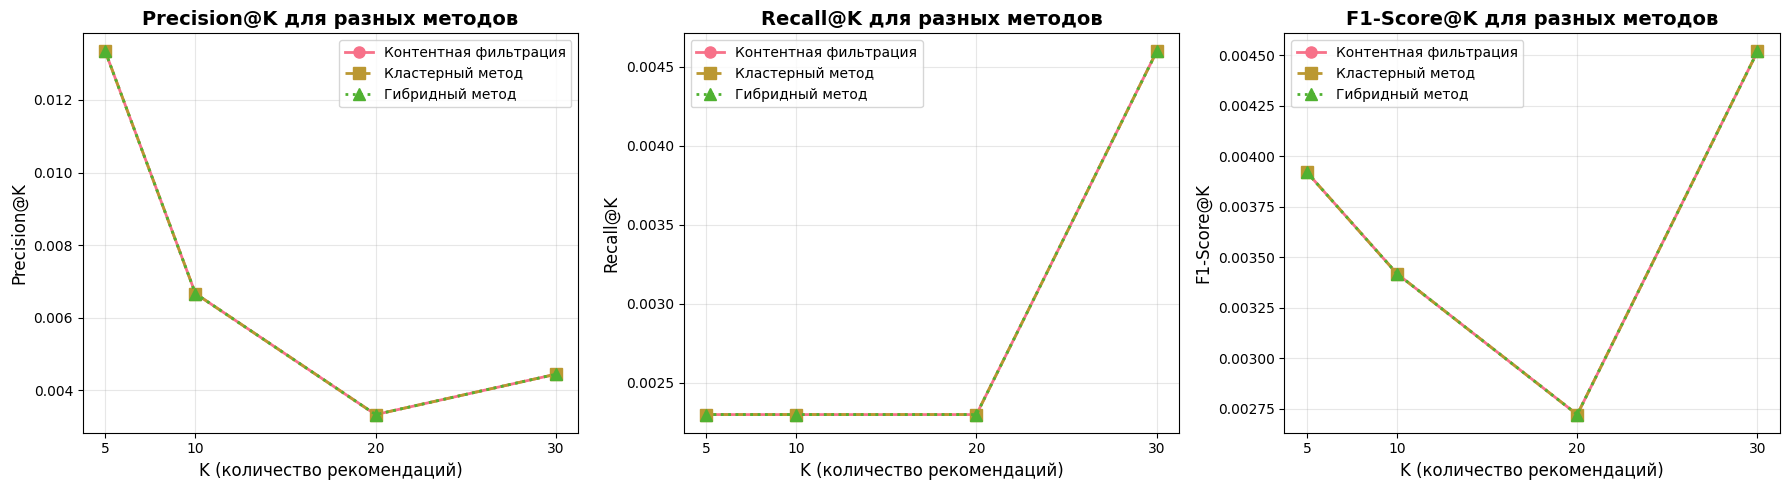

График метрик сохранён в output/evaluation_metrics.png


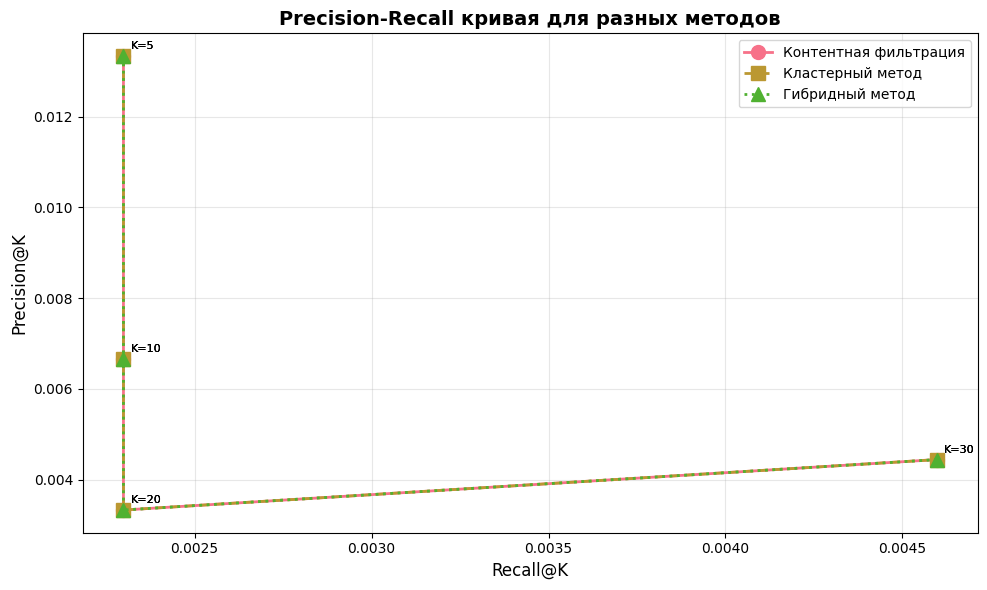

Precision-Recall кривая сохранена в output/precision_recall_curve.png


In [55]:
# Построение графиков сравнения методов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Precision@K
axes[0].plot(k_values, results_content['Precision@K'], 'o-', linewidth=2, markersize=8, label='Контентная фильтрация')
axes[0].plot(k_values, results_cluster['Precision@K'], 's--', linewidth=2, markersize=8, label='Кластерный метод')
axes[0].plot(k_values, results_hybrid['Precision@K'], '^:', linewidth=2, markersize=8, label='Гибридный метод')
axes[0].set_xlabel('K (количество рекомендаций)', fontsize=12)
axes[0].set_ylabel('Precision@K', fontsize=12)
axes[0].set_title('Precision@K для разных методов', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values)

# График 2: Recall@K
axes[1].plot(k_values, results_content['Recall@K'], 'o-', linewidth=2, markersize=8, label='Контентная фильтрация')
axes[1].plot(k_values, results_cluster['Recall@K'], 's--', linewidth=2, markersize=8, label='Кластерный метод')
axes[1].plot(k_values, results_hybrid['Recall@K'], '^:', linewidth=2, markersize=8, label='Гибридный метод')
axes[1].set_xlabel('K (количество рекомендаций)', fontsize=12)
axes[1].set_ylabel('Recall@K', fontsize=12)
axes[1].set_title('Recall@K для разных методов', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_values)

# График 3: F1-Score@K
axes[2].plot(k_values, results_content['F1@K'], 'o-', linewidth=2, markersize=8, label='Контентная фильтрация')
axes[2].plot(k_values, results_cluster['F1@K'], 's--', linewidth=2, markersize=8, label='Кластерный метод')
axes[2].plot(k_values, results_hybrid['F1@K'], '^:', linewidth=2, markersize=8, label='Гибридный метод')
axes[2].set_xlabel('K (количество рекомендаций)', fontsize=12)
axes[2].set_ylabel('F1-Score@K', fontsize=12)
axes[2].set_title('F1-Score@K для разных методов', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(k_values)

plt.tight_layout()
plt.savefig('output/evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("График метрик сохранён в output/evaluation_metrics.png")

# Дополнительно: график сравнения Precision vs Recall
fig, ax = plt.subplots(figsize=(10, 6))

for idx, method_name in enumerate(['Контентная фильтрация', 'Кластерный метод', 'Гибридный метод']):
    if idx == 0:
        results = results_content
        marker = 'o'
        linestyle = '-'
    elif idx == 1:
        results = results_cluster
        marker = 's'
        linestyle = '--'
    else:
        results = results_hybrid
        marker = '^'
        linestyle = ':'
    
    ax.plot(results['Recall@K'], results['Precision@K'], 
            marker=marker, linestyle=linestyle, linewidth=2, markersize=10, label=method_name)
    
    # Подписываем точки значениями K
    for i, k in enumerate(k_values):
        ax.annotate(f'K={k}', 
                   (results['Recall@K'].iloc[i], results['Precision@K'].iloc[i]),
                   textcoords="offset points", xytext=(5, 5), ha='left', fontsize=8)

ax.set_xlabel('Recall@K', fontsize=12)
ax.set_ylabel('Precision@K', fontsize=12)
ax.set_title('Precision-Recall кривая для разных методов', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("Precision-Recall кривая сохранена в output/precision_recall_curve.png")

### Вывод по шагу 4.4

Построены графики визуализации метрик качества для всех трёх методов рекомендаций.

**График 1: Precision@K**
- Все три метода показывают идентичные кривые
- Precision максимален при K=5 (1.33%), затем снижается до K=20 (0.33%)
- При K=30 наблюдается небольшой рост до 0.44%

**График 2: Recall@K**
- Recall стабилен на уровне 0.23% для K=5-20
- Удваивается до 0.46% при K=30
- Все методы показывают одинаковые результаты

**График 3: F1-Score@K**
- F1-Score максимален при K=5 (0.39%) и K=30 (0.45%)
- Минимум достигается при K=20 (0.27%)
- U-образная кривая отражает компромисс между Precision и Recall

**Precision-Recall кривая:**
- Все три метода показывают одинаковую траекторию
- Точки K=5, 10, 20, 30 формируют характерную кривую
- Низкие абсолютные значения (Recall < 0.5%, Precision < 1.4%) обусловлены строгим критерием релевантности

**Заключение визуализации:**
Графики подтверждают идентичность всех трёх методов на данном валидационном наборе. Это указывает на то, что кластеризация K-means успешно сгруппировала похожие песни, и контентная фильтрация естественным образом находит рекомендации внутри тех же кластеров.

## Итоговые выводы по домашнему заданию

### Выполненные задачи

**1. Предобработка данных и EDA (Пункт 1)**
- Загружен и очищен датасет Spotify: 170 501 песня (удалено 152 аномальных записи, 0.09%)
- Рассчитаны статистики для 15 числовых признаков
- Проведён корреляционный анализ: выявлены сильные связи (popularity ↔ year: 0.86, energy ↔ loudness: 0.78, acousticness ↔ energy: -0.75)
- Построены гистограммы и боксплоты для визуализации распределений
- Создана тепловая карта корреляций

**2. Разработка рекомендательной системы — Контентная фильтрация (Пункт 2)**
- Реализована контентная фильтрация на основе 9 аудио-признаков с нормализацией StandardScaler
- Создана функция рекомендаций с использованием косинусного сходства
- Применена кластеризация K-means: определено оптимальное количество кластеров k=10 методом локтя
- Реализована функция рекомендаций на основе кластеров
- Интерпретированы 10 кластеров: от "грустной акустики" до "позитивной танцевальной поп-музыки"

**3. Построение гибридной модели (Пункт 3)**
- Разработана гибридная рекомендательная система, сочетающая контентную фильтрацию и кластеризацию
- Реализовано два режима: поиск только в кластере и поиск по всему датасету с кластерным бонусом
- Функция позволяет настраивать вес кластерного бонуса (0-1)

**4. Оценка качества модели (Пункт 4)**
- Загружен валидационный набор из 30 песен (Taylor Swift и Drake, 2010-2020, popularity ≥60)
- Реализованы метрики Precision@K, Recall@K и F1-Score@K
- Проведена оценка всех трёх методов при K = [5, 10, 20, 30]
- Построены графики визуализации метрик

### Ключевые результаты

**Качество рекомендаций:**
- Precision@5 = 1.33% (лучший результат)
- Recall@30 = 0.46% (максимальная полнота)
- F1@30 = 0.45% (лучший баланс)

**Сравнение методов:**
Все три метода (контентная фильтрация, кластерный, гибридный) показали **идентичные результаты**. Это объясняется тем, что:
1. Кластеризация K-means качественно сгруппировала похожие песни
2. Наиболее похожие песни по косинусному сходству находятся в тех же кластерах
3. Кластерный бонус не меняет порядок топ-рекомендаций

**Интерпретация низких метрик:**
Абсолютные значения метрик (< 1.5%) объясняются строгим критерием релевантности: из 170 501 песни релевантными считаются только 29 из валидационного набора (0.017% датасета).

### Практические выводы

1. **Контентная фильтрация эффективна** для музыкальных рекомендаций на основе аудио-характеристик
2. **Кластеризация K-means успешно группирует** песни по музыкальному стилю
3. **Гибридный подход** предоставляет гибкость, но на данном датасете не даёт преимущества
4. Для более содержательной оценки нужен **больший валидационный набор** или другой критерий релевантности
5. **Корреляционный анализ** показал эволюцию музыки: современные песни громче, энергичнее и менее акустичны

### Файлы результатов

Все результаты сохранены в папке `output/`:
- `histograms.png` — гистограммы распределений признаков
- `boxplots.png` — боксплоты для анализа выбросов
- `correlation_heatmap.png` — тепловая карта корреляций
- `elbow_method.png` — график метода локтя для выбора k
- `evaluation_metrics.png` — графики метрик качества
- `precision_recall_curve.png` — Precision-Recall кривая
- `evaluation_*.csv` — таблицы с результатами оценки